# NSD predict

### data clean up
keeping only patient used for training and validation on best COMIND model

In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_path = "/home/dsemchin/data/data_ppmi_pd_with_best_model_subject_cols_with_subtype_probas.csv"
time_col = "time"
cat_levels = [1, 2, 3, 4, 5]

# Keep full longitudinal panel by default.
df_all = pd.read_csv(data_path)

print(df_all["NSD_STAGE"].value_counts(dropna=True))

def build_ordinal_panel(df, feature_cols):
    panel_df = df.copy()

    if "time" in panel_df.columns:
        panel_df["time"] = pd.to_numeric(panel_df["time"], errors="coerce") / 12.0
    
    nsd_raw = panel_df["NSD_STAGE"].astype(str).str.strip().str.lower()
    # map text variants first
    panel_df.loc[nsd_raw.isin(["2a", "2b"]), "NSD_STAGE"] = 2
    #panel_df.loc[nsd_raw.isin(["not nsd", "not_nsd", "none", "nan", ""]), "NSD_STAGE"] = np.nan

    panel_df["NSD_STAGE"] = pd.to_numeric(panel_df["NSD_STAGE"], errors="coerce")
    panel_df.loc[panel_df["NSD_STAGE"] == 0, "NSD_STAGE"] = np.nan
    # Merge sparse top class: stage 6 -> stage 5
    panel_df.loc[panel_df["NSD_STAGE"] == 6, "NSD_STAGE"] = 5

    panel_df["NSD_ordered"] = pd.Categorical(
        panel_df["NSD_STAGE"], categories=cat_levels, ordered=True
    )

    # Only require columns needed for current model.
    cols_needed = ["NSD_ordered", "subj_id", "model_split_best"] + feature_cols
    model_df = panel_df[cols_needed].copy()

    # Force predictors numeric, then drop NaN/inf rows.
    model_df[feature_cols] = model_df[feature_cols].apply(pd.to_numeric, errors="coerce")
    model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna(subset=cols_needed).copy()

    ord_train = model_df[model_df["model_split_best"] == "train"].copy()
    ord_val = model_df[model_df["model_split_best"] == "val"].copy()

    # Critical for OrderedModel stability: fit on observed train classes only.
    ord_train["NSD_ordered"] = pd.Categorical(
        ord_train["NSD_ordered"].astype(float), categories=cat_levels, ordered=True
    )
    ord_train["NSD_ordered"] = ord_train["NSD_ordered"].cat.remove_unused_categories()

    train_cats = ord_train["NSD_ordered"].cat.categories
    ord_val["NSD_ordered"] = pd.Categorical(
        ord_val["NSD_ordered"].astype(float), categories=train_cats, ordered=True
    )
    # Drop validation rows with classes not seen in train.
    ord_val = ord_val.dropna(subset=["NSD_ordered"]).copy()

    return model_df, ord_train, ord_val


base_features = [
    "MCATOT", "TD_score", "PIGD_score",   # clinical
    "beta_0", "beta_1", "beta_2",         # COMIND disease-time estimates
    "subtype_best",                       # COMIND subtype assignment
    "time",                               # visit timing
]
model_df, ord_train, ord_val = build_ordinal_panel(df_all, base_features)
full_cats = pd.Index(cat_levels)

print("\nRows by model_split_best:")
print(df_all["model_split_best"].value_counts(dropna=False))
print("\nUnique subjects by model_split_best:")
print(df_all.groupby("model_split_best")["subj_id"].nunique())
print("\nLongitudinal complete cases for base model:")
print("Train n:", len(ord_train), "| Val n:", len(ord_val))
print("Train NSD counts:\n", ord_train["NSD_ordered"].value_counts().sort_index())
print("Val NSD counts:\n", ord_val["NSD_ordered"].value_counts().sort_index())

NSD_STAGE
3          527
4          133
2b         131
Not NSD     46
5            8
2a           1
6            1
Name: count, dtype: int64

Rows by model_split_best:
model_split_best
train       513
not_used    235
val         132
Name: count, dtype: int64

Unique subjects by model_split_best:
model_split_best
not_used    231
train       116
val          30
Name: subj_id, dtype: int64

Longitudinal complete cases for base model:
Train n: 470 | Val n: 125
Train NSD counts:
 NSD_ordered
2     69
3    309
4     86
5      6
Name: count, dtype: int64
Val NSD counts:
 NSD_ordered
2    20
3    73
4    29
5     3
Name: count, dtype: int64


## Ablation

In [2]:
import itertools
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_absolute_error
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import kendalltau

from weighted_ordered_model import WeightedOrderedModel
from survival_ordered_regressors import *

from ord_dts import OrdinalDiscreteTimeSurvival, AdaBoostBinaryRegressor
from ord_dts_scoring import (
    ranked_probability_score,
    macro_ranked_probability_score,
    make_rps_scorer,
    make_macro_rps_scorer,
)


import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
#warnings.filterwarnings("ignore")

import random
random.seed(10)
np.random.seed(10)

# ── Feature Engineering ────────────────────────────────────────────────────

def add_model_features(df):
    df = df.copy()
    df["beta_assigned"] = np.select(
        [df["subtype_best"] == 0, df["subtype_best"] == 1, df["subtype_best"] == 2],
        [df["beta_0"],            df["beta_1"],             df["beta_2"]],
        default=np.nan
    )
    df["subtype_d1"] = (df["subtype_best"] == 1).astype(float)
    df["subtype_d2"] = (df["subtype_best"] == 2).astype(float)
    return df

def _encode_subtype(df, feat_cols):
    if "subtype_best" not in feat_cols:
        return df, feat_cols
    df = df.copy()
    if "subtype_d1" not in df.columns:
        df["subtype_d1"] = (df["subtype_best"] == 1).astype(float)
        df["subtype_d2"] = (df["subtype_best"] == 2).astype(float)
    new_cols = [c for c in feat_cols if c != "subtype_best"] + ["subtype_d1", "subtype_d2"]
    return df, new_cols

ord_train_fe = add_model_features(ord_train)
ord_val_fe   = add_model_features(ord_val)

# ── Ablations ──────────────────────────────────────────────────────────────

ABLATIONS = {
    "clinical only":          ["MCATOT", "TD_score", "PIGD_score", "time"],
    "betas only":             ["beta_0", "beta_1", "beta_2", "time"],
    "clinical+betas":         ["MCATOT", "TD_score", "PIGD_score", "time",
                               "beta_0", "beta_1", "beta_2"],
    "clinical+betas+subtype": ["MCATOT", "TD_score", "PIGD_score", "time",
                               "subtype_best", "beta_0", "beta_1", "beta_2"],
}

# ── Metrics ────────────────────────────────────────────────────────────────

def compute_metrics(y_true, y_pred, y_proba, classes, prefix=""):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    labs   = np.unique(y_true)
    sw     = compute_sample_weight("balanced", y_true)

    wacc   = accuracy_score(y_true, y_pred, sample_weight=sw)
    f1     = f1_score(y_true, y_pred, average="macro", labels=labs, zero_division=0)
    mae    = mean_absolute_error(y_true, y_pred)
    wmae   = mean_absolute_error(y_true, y_pred, sample_weight=sw)
    kappa  = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    tau, tau_p = kendalltau(y_true, y_pred)
    rps    = ranked_probability_score(y_true, y_proba, classes=classes)
    mrps   = macro_ranked_probability_score(y_true, y_proba, classes=classes)

    return {
        f"{prefix}rps":   round(rps,   4),   # ← primary selection metric
        f"{prefix}mrps":  round(mrps,  4),   # ← macro (rare-class sensitive)
        f"{prefix}wmae":  round(wmae,  4),
        f"{prefix}tau":   round(tau,   4),
        f"{prefix}tau_p": round(tau_p, 4),
        f"{prefix}kappa": round(kappa, 4),
        f"{prefix}f1":    round(f1,    4),
        f"{prefix}wacc":  round(wacc,  4),
        f"{prefix}mae":   round(mae,   4),
    }

# ── M1 grid — remove nm, it's unreliable for this problem ─────────────────
M1_GRID = list(itertools.product(
    ["logit", "probit", "cloglog"],
    ["bfgs", "lbfgs"],
))

def run_m1(y_tr, X_tr, y_v, X_v, distr, method):
    try:
        full_cats = y_tr.cat.categories
        w   = compute_sample_weight("balanced", y_tr.astype(float))
        mod = WeightedOrderedModel(y_tr, X_tr, sample_weights=w, distr=distr)
        res = mod.fit(method=method, disp=False, maxiter=1000, cov_type="HC1")

        if hasattr(res, "mle_retvals") and res.mle_retvals is not None:
            if not res.mle_retvals.get("converged", True):
                return None, None, None, None        # ← 4-tuple

        def _pred_and_proba(res, X):
            probs = res.model.predict(params=res.params, exog=X)  # (n, K)
            pred  = pd.Series(full_cats[np.argmax(probs, axis=1)],
                              index=X.index).astype(float)
            return pred, probs                                     # ← also return proba

        pred_tr, proba_tr = _pred_and_proba(res, X_tr)
        pred_v,  proba_v  = _pred_and_proba(res, X_v)
        return pred_tr, pred_v, proba_tr, proba_v                 # ← 4-tuple
    except Exception:
        return None, None, None, None

print("── M1 WeightedOrderedModel ───────────────────────────────────────────")
m1_results = []

for abl_name, feat_cols in ABLATIONS.items():
    ord_tr_m1, fc_m1 = _encode_subtype(ord_train_fe, feat_cols)
    ord_v_m1,  fc_m1 = _encode_subtype(ord_val_fe,   fc_m1)
    fc_m1 = [c for c in fc_m1 if c != "time"]

    y_tr = ord_tr_m1["NSD_ordered"].cat.remove_unused_categories()
    X_tr = ord_tr_m1[fc_m1].astype(float)
    y_v  = ord_v_m1["NSD_ordered"].cat.remove_unused_categories()
    X_v  = ord_v_m1[fc_m1].astype(float)

    classes     = y_tr.cat.categories.astype(float).to_numpy()
    best_rps, best_row = np.inf, None              # ← rps, minimise

    for distr, method in M1_GRID:
        pred_tr, pred_v, proba_tr, proba_v = run_m1(
            y_tr, X_tr, y_v, X_v, distr, method)
        if pred_v is None:
            continue
        val_m = compute_metrics(
            y_v.astype(float), pred_v, proba_v, classes, prefix="val_")
        if val_m["val_rps"] < best_rps:            # ← rps
            best_rps = val_m["val_rps"]
            best_row = {
                "model": "M1_WeightedOrdinal", "ablation": abl_name,
                "hp": f"{distr},{method}",
                **compute_metrics(
                    y_tr.astype(float), pred_tr, proba_tr, classes, prefix="train_"),
                **val_m,
            }

    if best_row:
        m1_results.append(best_row)
        print(f"  {abl_name:30s}  val_rps={best_rps:.4f}"        # ← rps
              f"  val_tau={best_row['val_tau']:.4f}  [{best_row['hp']}]")

# ── M2 ─────────────────────────────────────────────────────────────────────
M2_GRID = list(itertools.product(
    [50, 100, 200, 250, 300],
    [0.01, 0.025, 0.05, 0.1, 0.2, 0.5],
    ["square"],
    ["platt","prior",None],
    [0.2, 0.25],
))

def run_m2(train_df, y_tr, val_df, y_v, feat_cols,
           n_est, lr, loss, cal_method, cal_frac):
    train_df, feat_cols = _encode_subtype(train_df, feat_cols)
    val_df,   feat_cols = _encode_subtype(val_df,   feat_cols)
    try:
        order   = np.sort(np.unique(y_tr))
        X_tr_m2 = train_df[["subj_id", "time"] + feat_cols].copy()
        X_v_m2  = val_df[["subj_id",  "time"] + feat_cols].copy()
        mod = OrdinalDiscreteTimeSurvival(
            order=order,
            base_estimator=AdaBoostBinaryRegressor(
                n_estimators=n_est, learning_rate=lr,
                loss=loss, random_state=0),
            subj_id_col="subj_id", time_col="time",
            include_visit_index=True,
            class_weight="balanced",
            enforce_threshold_ordering=True,
            calibration_method=cal_method,
            calibration_fraction=cal_frac,
            calibration_random_state=0,
        )
        mod.fit(X_tr_m2, y_tr)
        proba_tr = mod.predict_proba(X_tr_m2)
        proba_v  = mod.predict_proba(X_v_m2)
        pred_tr  = mod.predict(X_tr_m2)
        pred_v   = mod.predict(X_v_m2)
        return pred_tr, pred_v, proba_tr, proba_v
    except Exception:
        return None, None, None, None

print("\n── M2 SurvivalAdaBoost ───────────────────────────────────────────────")
m2_results = []

for abl_name, feat_cols in ABLATIONS.items():                    # ← outer loop
    feat_cols_m2 = [c for c in feat_cols if c != "time"]
    y_tr    = ord_train_fe["NSD_ordered"].astype(float).to_numpy()
    y_v     = ord_val_fe["NSD_ordered"].astype(float).to_numpy()
    classes = np.sort(np.unique(y_tr))

    best_rps, best_row = np.inf, None                            # ← rps not wmae

    for n_est, lr, loss, cal_method, cal_frac in M2_GRID:       # ← indented in
        pred_tr, pred_v, proba_tr, proba_v = run_m2(
            ord_train_fe, y_tr, ord_val_fe, y_v,
            feat_cols_m2, n_est, lr, loss, cal_method, cal_frac)
        if pred_v is None:
            continue
        val_m = compute_metrics(y_v, pred_v, proba_v, classes, prefix="val_")
        if val_m["val_mrps"] < best_rps:
            best_rps = val_m["val_mrps"]
            best_row = {
                "model": "M2_SurvivalAdaBoost", "ablation": abl_name,
                "hp": f"n={n_est},lr={lr},loss={loss},"
                      f"cal={cal_method},frac={cal_frac}",
                **compute_metrics(y_tr, pred_tr, proba_tr, classes, prefix="train_"),
                **val_m,
            }

    if best_row:                                                  # ← indented in
        m2_results.append(best_row)
        print(f"  {abl_name:30s}  val_mrps={best_rps:.4f}"        # ← rps not wmae
              f"  val_tau={best_row['val_tau']:.4f}  [{best_row['hp']}]")

# ── M3 ─────────────────────────────────────────────────────────────────────
# Per advisor: lbfgs only, no L1/SAGA, no/weak regularization
M3_GRID = list(itertools.product(
    [None],                # penalty — no regularization per advisor
    [1.0],                 # C — ignored when penalty=None
    [True, False],         # include_visit_index
    [True, False],         # enforce_threshold_ordering
    ["platt","prior",None],             # calibration_method  ← new
    [0.2, 0.25],           # calibration_fraction ← new
))

def run_m3(train_df, y_tr, val_df, y_v, feat_cols,
           penalty, C, visit_idx, enforce, cal_method, cal_frac):  # ← new params
    try:
        train_df, feat_cols = _encode_subtype(train_df, feat_cols)
        val_df,   feat_cols = _encode_subtype(val_df,   feat_cols)
        order   = np.sort(np.unique(y_tr))
        X_tr_m3 = train_df[["subj_id", "time"] + feat_cols].copy()
        X_v_m3  = val_df[["subj_id",  "time"] + feat_cols].copy()
        scaler  = StandardScaler()
        X_tr_m3[feat_cols] = scaler.fit_transform(X_tr_m3[feat_cols].astype(float))
        X_v_m3[feat_cols]  = scaler.transform(X_v_m3[feat_cols].astype(float))
        mod = OrdinalDiscreteTimeSurvival(
            order=order,
            base_estimator=LogisticRegression(
                penalty=penalty,
                C=C if penalty is not None else 1.0,
                solver="lbfgs",
                max_iter=1000,
                random_state=0,
                class_weight=None,
            ),
            subj_id_col="subj_id", time_col="time",
            include_visit_index=visit_idx,
            class_weight="balanced",
            enforce_threshold_ordering=enforce,
            calibration_method=cal_method,         # ← replaces calibrate=True
            calibration_fraction=cal_frac,         # ← new
            calibration_random_state=0,            # ← new
        )
        mod.fit(X_tr_m3, y_tr)
        proba_tr = mod.predict_proba(X_tr_m3)      # ← new
        proba_v  = mod.predict_proba(X_v_m3)       # ← new
        pred_tr  = mod.predict(X_tr_m3)
        pred_v   = mod.predict(X_v_m3)
        return pred_tr, pred_v, proba_tr, proba_v  # ← 4-tuple
    except Exception:
        return None, None, None, None

print("\n── M3 SurvivalLogistic ───────────────────────────────────────────────")
m3_results = []

for abl_name, feat_cols in ABLATIONS.items():
    feat_cols_m3 = [c for c in feat_cols if c != "time"]
    y_tr    = ord_train_fe["NSD_ordered"].astype(float).to_numpy()
    y_v     = ord_val_fe["NSD_ordered"].astype(float).to_numpy()
    classes = np.sort(np.unique(y_tr))

    best_rps, best_row = np.inf, None              # ← rps not wmae

    for penalty, C, visit_idx, enforce, cal_method, cal_frac in M3_GRID:  # ← unpack 6
        pred_tr, pred_v, proba_tr, proba_v = run_m3(
            ord_train_fe, y_tr, ord_val_fe, y_v,
            feat_cols_m3, penalty, C, visit_idx, enforce, cal_method, cal_frac)
        if pred_v is None:
            continue
        val_m = compute_metrics(y_v, pred_v, proba_v, classes, prefix="val_")
        if val_m["val_mrps"] < best_rps:            # ← rps
            best_rps = val_m["val_mrps"]
            best_row = {
                "model": "M3_SurvivalLogistic", "ablation": abl_name,
                "hp": f"penalty={penalty},C={C},visit={visit_idx},"
                      f"enforce={enforce},cal={cal_method},frac={cal_frac}",
                **compute_metrics(y_tr, pred_tr, proba_tr, classes, prefix="train_"),
                **val_m,
            }

    if best_row:
        m3_results.append(best_row)
        print(f"  {abl_name:30s}  val_mrps={best_rps:.4f}"        # ← rps
              f"  val_tau={best_row['val_tau']:.4f}  [{best_row['hp']}]")

# ── M4 SurvivalSVM ─────────────────────────────────────────────────────────
from sklearn.svm import SVC

class SVMBinaryClassifier(BaseEstimator):
    def __init__(self, C=1.0, kernel="rbf", gamma="scale", random_state=None):
        self.C            = C
        self.kernel       = kernel
        self.gamma        = gamma
        self.random_state = random_state

    def fit(self, X, y, sample_weight=None):
        self.clf_ = SVC(
            C=self.C,
            kernel=self.kernel,
            gamma=self.gamma,
            probability=False,         # ← OrdinalDiscreteTimeSurvival handles calibration
            random_state=self.random_state,
            class_weight=None,
        )
        self.clf_.fit(X, y.astype(int), sample_weight=sample_weight)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        check_is_fitted(self, "clf_")
        # Use decision function scores converted to pseudo-probabilities via sigmoid
        scores = self.clf_.decision_function(X)
        p1 = 1.0 / (1.0 + np.exp(-scores))
        p1 = np.clip(p1, 1e-6, 1.0 - 1e-6)
        return np.column_stack([1.0 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

M4_GRID = list(itertools.product(
    [0.1, 1.0, 10.0, 100.0],          # C — SVM regularization
    ["rbf", "linear"],                 # kernel
    [True, False],                     # include_visit_index
    [True, False],                     # enforce_threshold_ordering
    ["platt","prior",None],                         # calibration_method ← new
    [0.2, 0.25],                       # calibration_fraction ← new
))

def run_m4(train_df, y_tr, val_df, y_v, feat_cols,
           C, kernel, visit_idx, enforce, cal_method, cal_frac):  # ← new params
    try:
        train_df, feat_cols = _encode_subtype(train_df, feat_cols)
        val_df,   feat_cols = _encode_subtype(val_df,   feat_cols)
        order   = np.sort(np.unique(y_tr))
        X_tr_m4 = train_df[["subj_id", "time"] + feat_cols].copy()
        X_v_m4  = val_df[["subj_id",  "time"] + feat_cols].copy()
        scaler  = StandardScaler()
        X_tr_m4[feat_cols] = scaler.fit_transform(X_tr_m4[feat_cols].astype(float))
        X_v_m4[feat_cols]  = scaler.transform(X_v_m4[feat_cols].astype(float))
        mod = OrdinalDiscreteTimeSurvival(
            order=order,
            base_estimator=SVMBinaryClassifier(C=C, kernel=kernel),
            subj_id_col="subj_id", time_col="time",
            include_visit_index=visit_idx,
            class_weight="balanced",
            enforce_threshold_ordering=enforce,
            calibration_method=cal_method,         # ← replaces calibrate=False
            calibration_fraction=cal_frac,         # ← new
            calibration_random_state=0,            # ← new
        )
        mod.fit(X_tr_m4, y_tr)
        proba_tr = mod.predict_proba(X_tr_m4)      # ← new
        proba_v  = mod.predict_proba(X_v_m4)       # ← new
        pred_tr  = mod.predict(X_tr_m4)
        pred_v   = mod.predict(X_v_m4)
        return pred_tr, pred_v, proba_tr, proba_v  # ← 4-tuple
    except Exception:
        return None, None, None, None


print("\n── M4 SurvivalSVM ────────────────────────────────────────────────────")
m4_results = []

for abl_name, feat_cols in ABLATIONS.items():
    feat_cols_m4 = [c for c in feat_cols if c != "time"]
    y_tr    = ord_train_fe["NSD_ordered"].astype(float).to_numpy()
    y_v     = ord_val_fe["NSD_ordered"].astype(float).to_numpy()
    classes = np.sort(np.unique(y_tr))

    best_rps, best_row = np.inf, None

    for C, kernel, visit_idx, enforce, cal_method, cal_frac in M4_GRID:  # ← unpack 6
        pred_tr, pred_v, proba_tr, proba_v = run_m4(
            ord_train_fe, y_tr, ord_val_fe, y_v,
            feat_cols_m4, C, kernel, visit_idx, enforce, cal_method, cal_frac)
        if pred_v is None:
            continue
        val_m = compute_metrics(y_v, pred_v, proba_v, classes, prefix="val_")
        if val_m["val_mrps"] < best_rps:
            best_rps = val_m["val_mrps"]
            best_row = {
                "model": "M4_SurvivalSVM", "ablation": abl_name,
                "hp": f"C={C},kernel={kernel},visit={visit_idx},"
                      f"enforce={enforce},cal={cal_method},frac={cal_frac}",
                **compute_metrics(y_tr, pred_tr, proba_tr, classes, prefix="train_"),
                **val_m,
            }

    if best_row:
        m4_results.append(best_row)
        print(f"  {abl_name:30s}  val_mrps={best_rps:.4f}"
              f"  val_tau={best_row['val_tau']:.4f}  [{best_row['hp']}]")

# ── update all_results ─────────────────────────────────────────────────────
all_results = pd.DataFrame(m1_results + m2_results + m3_results + m4_results)

KEY_COLS = ["model", "ablation", "hp",
            "train_rps", "val_rps", "val_mrps",
            "val_tau", "val_tau_p", "val_wmae",
            "val_kappa", "val_f1"]

print("\n\n══ FULL ABLATION SUMMARY (sorted by val_mrps) ════════════════════════")
summary = all_results[KEY_COLS].sort_values("val_mrps", ascending=True)
pd.set_option("display.max_colwidth", 35)
pd.set_option("display.float_format", "{:.4f}".format)
display(summary)

best = all_results.loc[all_results["val_mrps"].idxmin()]
print(f"\n★  Best overall:  {best['model']}  |  {best['ablation']}")
print(f"   val_wmae={best['val_wmae']:.4f}  val_tau={best['val_tau']:.4f}"
      f"  (p={best['val_tau_p']:.4f})  val_f1={best['val_f1']:.4f}")

── M1 WeightedOrderedModel ───────────────────────────────────────────
  clinical only                   val_rps=0.5147  val_tau=0.3514  [logit,bfgs]
  betas only                      val_rps=0.4817  val_tau=-0.0322  [probit,bfgs]
  clinical+betas                  val_rps=0.5065  val_tau=0.2939  [logit,bfgs]
  clinical+betas+subtype          val_rps=0.5443  val_tau=0.2877  [logit,lbfgs]

── M2 SurvivalAdaBoost ───────────────────────────────────────────────
  clinical only                   val_mrps=0.4373  val_tau=0.3915  [n=50,lr=0.01,loss=square,cal=None,frac=0.2]
  betas only                      val_mrps=0.5663  val_tau=0.3496  [n=250,lr=0.01,loss=square,cal=None,frac=0.2]
  clinical+betas                  val_mrps=0.4321  val_tau=0.4012  [n=50,lr=0.01,loss=square,cal=None,frac=0.2]
  clinical+betas+subtype          val_mrps=0.4273  val_tau=0.4287  [n=50,lr=0.01,loss=square,cal=None,frac=0.2]

── M3 SurvivalLogistic ───────────────────────────────────────────────
  clinical only  

,model,ablation,hp,train_rps,val_rps,val_mrps,val_tau,val_tau_p,val_wmae,val_kappa,val_f1
8,M3_SurvivalLogistic,clinical only,"penalty=None,C=1.0,visit=True,e...",0.2384,0.3698,0.4045,0.3661,0.0000,0.5789,0.3709,0.2914
12,M4_SurvivalSVM,clinical only,"C=10.0,kernel=linear,visit=True...",0.2372,0.3721,0.4100,0.3603,0.0000,0.5824,0.3673,0.2882
7,M2_SurvivalAdaBoost,clinical+betas+subtype,"n=50,lr=0.01,loss=square,cal=No...",0.4389,0.4884,0.4273,0.4287,0.0000,0.5711,0.3596,0.3646
6,M2_SurvivalAdaBoost,clinical+betas,"n=50,lr=0.01,loss=square,cal=No...",0.4799,0.4923,0.4321,0.4012,0.0000,0.5781,0.3448,0.3734
4,M2_SurvivalAdaBoost,clinical only,"n=50,lr=0.01,loss=square,cal=No...",0.5087,0.5252,0.4373,0.3915,0.0000,0.6261,0.3024,0.3274
14,M4_SurvivalSVM,clinical+betas,"C=0.1,kernel=linear,visit=True,...",0.2371,0.3383,0.4439,0.4497,0.0000,0.5517,0.4637,0.3574
15,M4_SurvivalSVM,clinical+betas+subtype,"C=100.0,kernel=rbf,visit=True,e...",0.2602,0.5188,0.4537,0.2430,0.0023,0.6419,0.2560,0.3412
0,M1_WeightedOrdinal,clinical only,"logit,bfgs",0.4000,0.5147,0.4685,0.3514,0.0000,0.7000,0.3499,0.2913
2,M1_WeightedOrdinal,clinical+betas,"logit,bfgs",0.4066,0.5065,0.4910,0.2939,0.0002,0.7501,0.3071,0.2776
3,M1_WeightedOrdinal,clinical+betas+subtype,"logit,lbfgs",0.4075,0.5443,0.5212,0.2877,0.0002,0.8107,0.2585,0.2340



★  Best overall:  M3_SurvivalLogistic  |  clinical only
   val_wmae=0.5789  val_tau=0.3661  (p=0.0000)  val_f1=0.2914


In [10]:
all_results.loc[14,'hp']
# all_results.loc[14,'val_mrps']
# all_results.loc[14,'val_wmae']
# all_results.loc[14,'val_tau']
# all_results.loc[14,'val_tau_p']
# all_results.loc[14,'val_f1']


'C=0.1,kernel=linear,visit=True,enforce=False,cal=prior,frac=0.2'

In [3]:
print(all_results["model"].value_counts())

model
M1_WeightedOrdinal     4
M2_SurvivalAdaBoost    4
M3_SurvivalLogistic    4
M4_SurvivalSVM         4
Name: count, dtype: int64


★  Refitting best model: M4_SurvivalSVM  |  clinical+betas  |  C=0.1,kernel=linear,visit=True,enforce=False,cal=prior,frac=0.2

Metric                      Train        Val
────────────────────────────────────────────
  RPS (plain)              0.2371     0.3383
  RPS (macro)              0.5400     0.4439
  Weighted MAE             0.8475     0.5517
  Kendall τ                0.3375     0.4497
    τ p-value              0.0000     0.0000
  Quadratic κ              0.2799     0.4637
  Macro F1                 0.3110     0.3574
  Weighted accuracy        0.3192     0.4586

  ⚠  Train/val RPS gap = 0.101 — possible overfitting.

  Features used: ['MCATOT', 'TD_score', 'PIGD_score', 'time', 'beta_0', 'beta_1', 'beta_2']


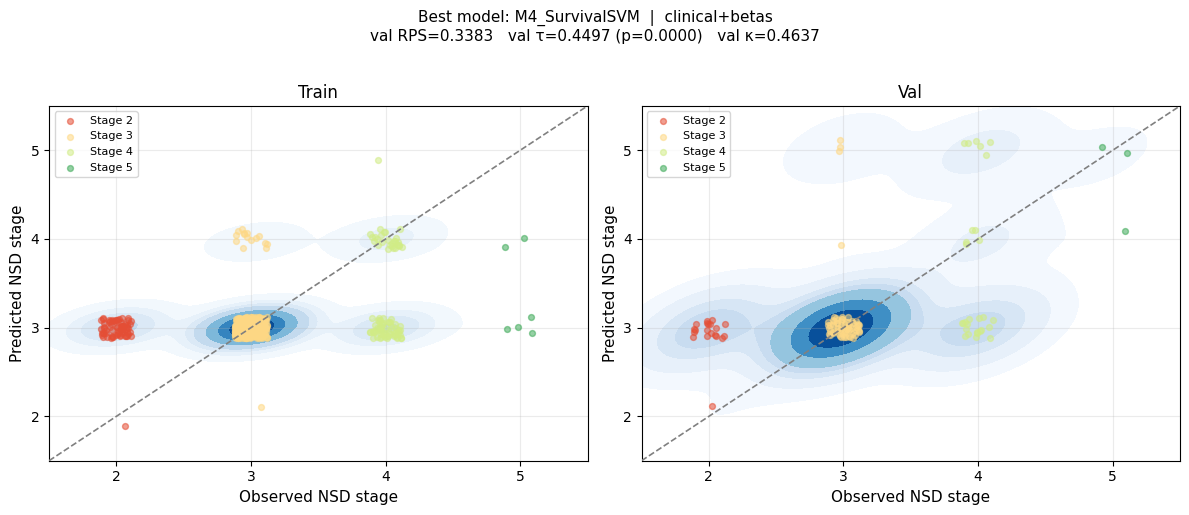

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#best = all_results[14]
best = all_results.loc[all_results["val_wmae"].idxmin()].copy()   # ← fixed
print(f"★  Refitting best model: {best['model']}  |  {best['ablation']}  |  {best['hp']}")

feat_cols = ABLATIONS[best["ablation"]]

# ── Reconstruct features & refit ──────────────────────────────────────────

if best["model"] == "M1_WeightedOrdinal":
    distr, method = best["hp"].split(",")
    ord_train_m1, feat_cols_m1 = _encode_subtype(ord_train_fe, feat_cols)
    ord_val_m1,   feat_cols_m1 = _encode_subtype(ord_val_fe,   feat_cols_m1)
    feat_cols_m1 = [c for c in feat_cols_m1 if c != "time"]
    y_tr     = ord_train_m1["NSD_ordered"].cat.remove_unused_categories()
    X_tr     = ord_train_m1[feat_cols_m1].astype(float)
    y_v      = ord_val_m1["NSD_ordered"].cat.remove_unused_categories()
    X_v      = ord_val_m1[feat_cols_m1].astype(float)
    pred_tr, pred_v, proba_tr, proba_v = run_m1(   # ← 4-tuple
        y_tr, X_tr, y_v, X_v, distr, method)
    y_tr_num = y_tr.astype(float).to_numpy()
    y_v_num  = y_v.astype(float).to_numpy()
    classes  = y_tr.cat.categories.astype(float).to_numpy()

elif best["model"] == "M2_SurvivalAdaBoost":
    hp = dict(item.split("=") for item in best["hp"].split(","))
    feat_cols_m2 = [c for c in feat_cols if c != "time"]
    y_tr_num = ord_train_fe["NSD_ordered"].astype(float).to_numpy()
    y_v_num  = ord_val_fe["NSD_ordered"].astype(float).to_numpy()
    classes  = np.sort(np.unique(y_tr_num))
    pred_tr, pred_v, proba_tr, proba_v = run_m2(   # ← 4-tuple, fixed params
        ord_train_fe, y_tr_num, ord_val_fe, y_v_num,
        feat_cols_m2,
        n_est=int(hp["n"]),
        lr=float(hp["lr"]),
        loss=hp.get("loss", "square"),
        cal_method=hp.get("cal", "platt"),           # ← cal_method not cal
        cal_frac=float(hp.get("frac", 0.25)),        # ← cal_frac
    )

elif best["model"] == "M4_SurvivalSVM":
    hp = dict(item.split("=") for item in best["hp"].split(","))
    feat_cols_m4 = [c for c in feat_cols if c != "time"]
    y_tr_num = ord_train_fe["NSD_ordered"].astype(float).to_numpy()
    y_v_num  = ord_val_fe["NSD_ordered"].astype(float).to_numpy()
    classes  = np.sort(np.unique(y_tr_num))
    pred_tr, pred_v, proba_tr, proba_v = run_m4(   # ← 4-tuple, fixed params
        ord_train_fe, y_tr_num, ord_val_fe, y_v_num,
        feat_cols_m4,
        C=float(hp["C"]),
        kernel=hp["kernel"],
        visit_idx=hp.get("visit", "True") == "True",
        enforce=hp.get("enforce", "True") == "True",
        cal_method=hp.get("cal", "platt"),           # ← new
        cal_frac=float(hp.get("frac", 0.25)),        # ← new
    )

else:  # M3_SurvivalLogistic
    hp = dict(item.split("=") for item in best["hp"].split(","))
    feat_cols_m3 = [c for c in feat_cols if c != "time"]
    y_tr_num = ord_train_fe["NSD_ordered"].astype(float).to_numpy()
    y_v_num  = ord_val_fe["NSD_ordered"].astype(float).to_numpy()
    classes  = np.sort(np.unique(y_tr_num))
    penalty  = None if hp["penalty"] == "None" else hp["penalty"]
    pred_tr, pred_v, proba_tr, proba_v = run_m3(   # ← 4-tuple, fixed params
        ord_train_fe, y_tr_num, ord_val_fe, y_v_num,
        feat_cols_m3,
        penalty=penalty,
        C=float(hp["C"]),
        visit_idx=hp.get("visit", "True") == "True",
        enforce=hp.get("enforce", "True") == "True",
        cal_method=hp.get("cal", "platt"),           # ← new
        cal_frac=float(hp.get("frac", 0.25)),        # ← new
    )

pred_tr  = np.asarray(pred_tr,  dtype=float)
pred_v   = np.asarray(pred_v,   dtype=float)

# ── Metrics printout ───────────────────────────────────────────────────────

tr_m = compute_metrics(y_tr_num, pred_tr, proba_tr, classes, prefix="train_")  # ← fixed
v_m  = compute_metrics(y_v_num,  pred_v,  proba_v,  classes, prefix="val_")    # ← fixed

labels = {
    "rps":   "RPS (plain)",
    "mrps":  "RPS (macro)",
    "wmae":  "Weighted MAE",
    "tau":   "Kendall τ",
    "tau_p": "  τ p-value",
    "kappa": "Quadratic κ",
    "f1":    "Macro F1",
    "wacc":  "Weighted accuracy",
}
print(f"\n{'Metric':<22} {'Train':>10} {'Val':>10}")
print("─" * 44)
for key, label in labels.items():
    print(f"  {label:<20} {tr_m[f'train_{key}']:>10.4f} {v_m[f'val_{key}']:>10.4f}")

gap = v_m["val_rps"] - tr_m["train_rps"]
if gap > 0.05:
    print(f"\n  ⚠  Train/val RPS gap = {gap:.3f} — possible overfitting.")

print(f"\n  Features used: {feat_cols}")

# ── KDE plot ───────────────────────────────────────────────────────────────

stage_range = (1.5, 5.5)
jitter      = 0.12
rng         = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"Best model: {best['model']}  |  {best['ablation']}\n"
    f"val RPS={v_m['val_rps']:.4f}   "
    f"val τ={v_m['val_tau']:.4f} (p={v_m['val_tau_p']:.4f})   "
    f"val κ={v_m['val_kappa']:.4f}",
    fontsize=11, y=1.02
)

for ax, y_true, y_pred, split in [
    (axes[0], y_tr_num, pred_tr, "Train"),
    (axes[1], y_v_num,  pred_v,  "Val"),
]:
    stages  = np.unique(y_true)
    palette = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(stages)))

    sns.kdeplot(
        x=y_true + rng.uniform(-jitter, jitter, len(y_true)),
        y=y_pred + rng.uniform(-jitter, jitter, len(y_pred)),
        fill=True, cmap="Blues", thresh=0.05, levels=8, ax=ax
    )
    for stage, col in zip(stages, palette):
        mask = y_true == stage
        ax.scatter(
            y_true[mask] + rng.uniform(-jitter, jitter, mask.sum()),
            y_pred[mask] + rng.uniform(-jitter, jitter, mask.sum()),
            color=col, alpha=0.55, s=18, label=f"Stage {int(stage)}", zorder=3
        )

    lo, hi = stage_range
    ax.plot([lo, hi], [lo, hi], ls="--", c="gray", lw=1.2, zorder=4)
    ax.set_xlim(lo, hi);  ax.set_ylim(lo, hi)
    ax.set_xlabel("Observed NSD stage", fontsize=11)
    ax.set_ylabel("Predicted NSD stage", fontsize=11)
    ax.set_title(split, fontsize=12)
    ax.set_xticks(sorted(stages));  ax.set_yticks(sorted(stages))
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("best_model_kde.png", dpi=150, bbox_inches="tight")
plt.show()

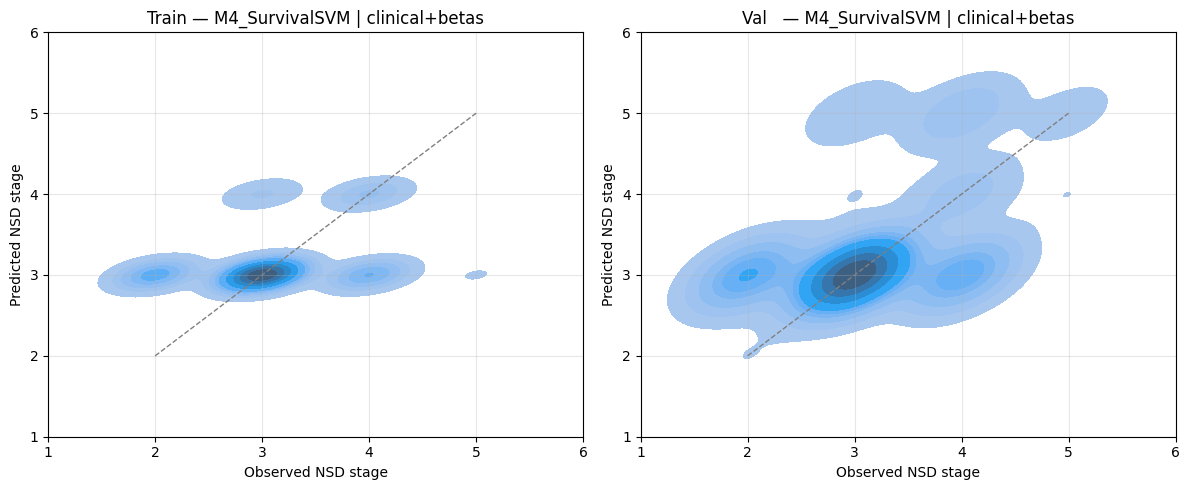

In [8]:
# ── Plain KDE plot ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true, pred, title in [
    (axes[0], y_tr_num, pred_tr, f"Train — {best['model']} | {best['ablation']}"),
    (axes[1], y_v_num,  pred_v,  f"Val   — {best['model']} | {best['ablation']}"),
]:
    sns.kdeplot(x=true.astype(float), y=pred.astype(float), fill=True, ax=ax)
    lo, hi = float(np.min(true)), float(np.max(true))
    ax.plot([lo, hi], [lo, hi], ls="--", c="gray", lw=1)
    ax.set_xlabel("Observed NSD stage")
    ax.set_ylabel("Predicted NSD stage")
    ax.set_xlim(1, 6)
    ax.set_ylim(1, 6)
    ax.set_title(title)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("best_model_kde_plain.png", dpi=150, bbox_inches="tight")
plt.show()